### Decision Tree — Modeling

A decision tree learns a series of yes/no questions about your features to predict the target. It's easy to interpret because you can visualise the exact rules it learned.

**Compared to logistic regression:**
- No need to scale features
- Handles non-linear relationships automatically
- Fully interpretable — you can read every decision
- Prone to overfitting if the tree grows too deep

---

### Step 1 — Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

---
### Step 2 — Load & Split the Data

Same split as the logistic regression baseline — 80/20, stratified.

In [3]:
df = pd.read_csv('data/features_encoded_train.csv')

X = df.drop(columns=['target_bank_account'])
y = df['target_bank_account']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training rows  : {X_train.shape[0]:,}')
print(f'Validation rows: {X_val.shape[0]:,}')

# Note: no scaling needed — decision trees are scale-invariant

Training rows  : 18,819
Validation rows: 4,705


---
### Step 3 — Train the Decision Tree

`max_depth` is the most important setting. Without it the tree grows until every leaf is pure — this causes **overfitting** (the model memorises training data but fails on new data).

We start with `max_depth=4` as a sensible baseline — deep enough to learn patterns, shallow enough to stay interpretable.

In [5]:
tree = DecisionTreeClassifier(
    max_depth=4,             # limits tree size — prevents overfitting
    class_weight='balanced', # handles the 86/14 class imbalance
    random_state=42
)

tree.fit(X_train, y_train)

print(f'   Tree depth : {tree.get_depth()}')
print(f'   Leaf nodes : {tree.get_n_leaves()}')

   Tree depth : 4
   Leaf nodes : 16


---
### Step 4 — Evaluate

Same metrics as the logistic regression baseline so we can compare directly.

In [7]:
y_proba = tree.predict_proba(X_val)[:, 1]
y_pred  = tree.predict(X_val)

auc = roc_auc_score(y_val, y_proba)
print(f'ROC-AUC: {auc:.4f}  (baseline logistic regression = 0.8575)')
print()
print(classification_report(y_val, y_pred,
      target_names=['No bank account', 'Has bank account']))

ROC-AUC: 0.8197  (baseline logistic regression = 0.8575)

                  precision    recall  f1-score   support

 No bank account       0.93      0.86      0.89      4043
Has bank account       0.42      0.61      0.50       662

        accuracy                           0.83      4705
       macro avg       0.67      0.74      0.70      4705
    weighted avg       0.86      0.83      0.84      4705



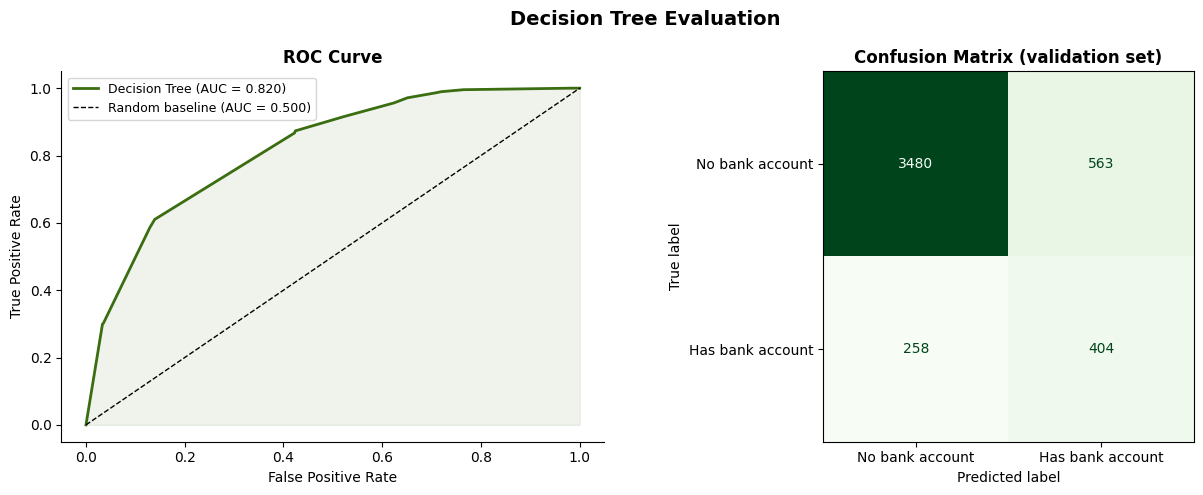

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_proba)
axes[0].plot(fpr, tpr, color='#3B6D11', lw=2, label=f'Decision Tree (AUC = {auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1, label='Random baseline (AUC = 0.500)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#3B6D11')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No bank account', 'Has bank account']).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix (validation set)', fontweight='bold')

plt.suptitle('Decision Tree Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
### Step 5 — Visualise the Tree

This is the key advantage of a decision tree — you can read exactly what rules it learned. Each node shows:
- The question being asked (e.g. `cellphone_access <= 0.5`)
- How many samples reach that node
- The predicted class at that node

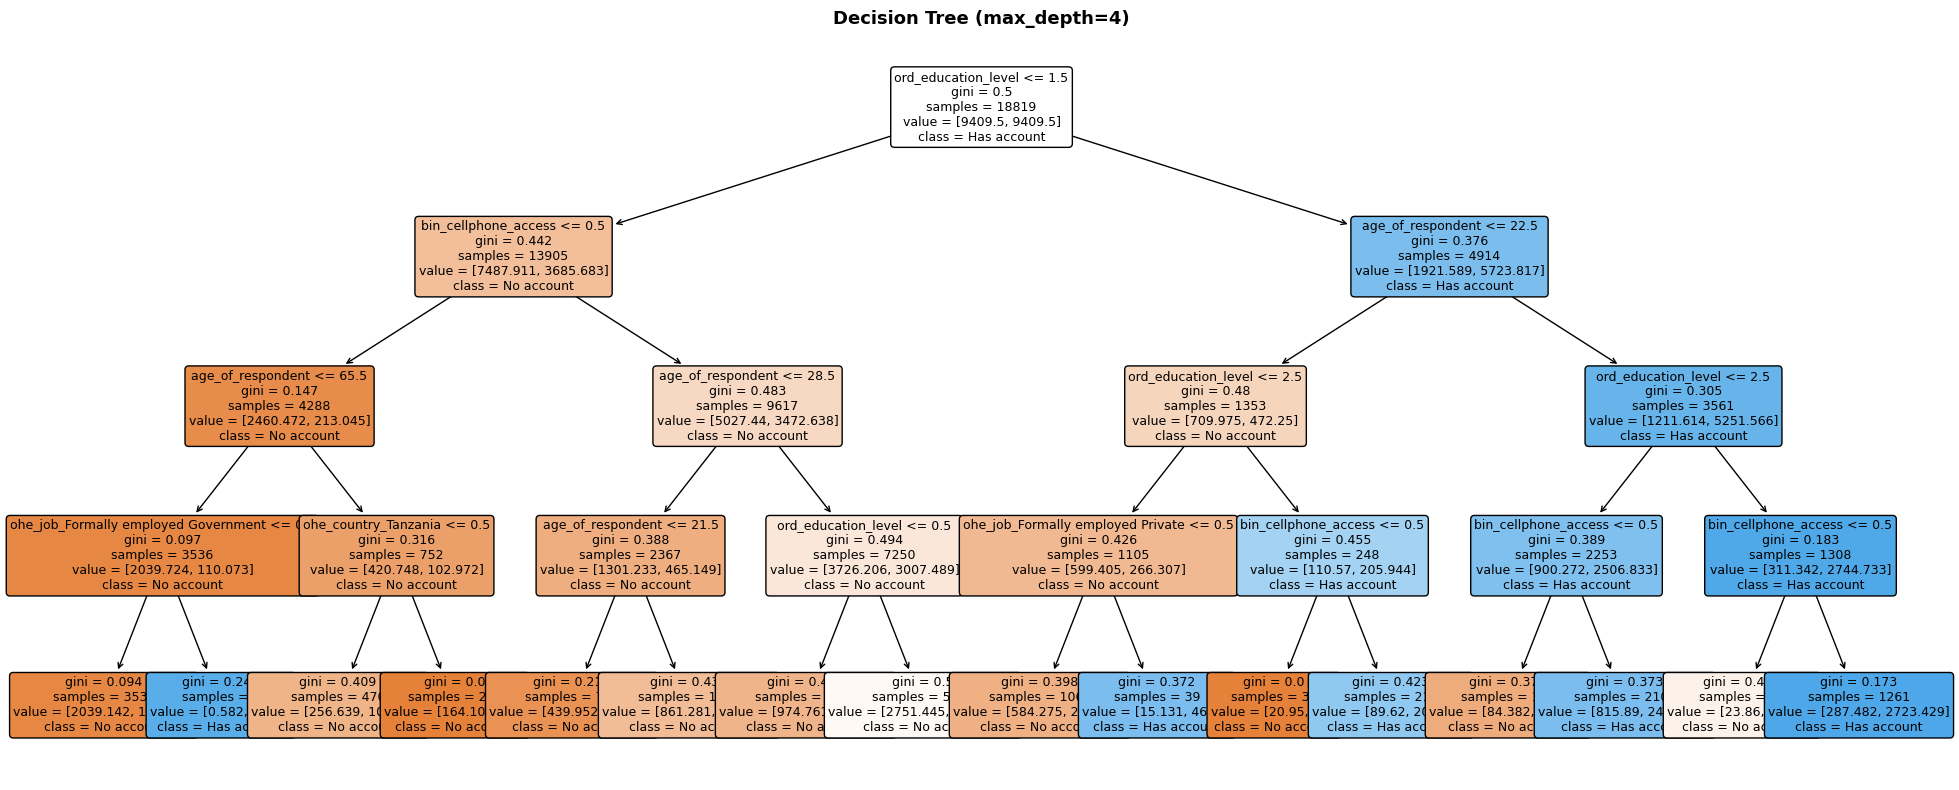

Blue nodes → predicts "Has bank account"
Orange nodes → predicts "No bank account"
Darker colour = more confident prediction


In [ ]:
fig, ax = plt.subplots(figsize=(20, 8))

plot_tree(
    tree,
    feature_names=X_train.columns,
    class_names=['No account', 'Has account'],
    filled=True,       # colour nodes by predicted class
    rounded=True,      # rounded corners
    fontsize=9,
    ax=ax
)

ax.set_title('Decision Tree (max_depth=4)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Blue nodes → predicts "Has bank account"')
print('Orange nodes → predicts "No bank account"')
print('Darker colour = more confident prediction')

---
### Step 6 — Feature Importance

The decision tree ranks features by how much they reduce impurity across all splits. Higher = more useful for predictions.

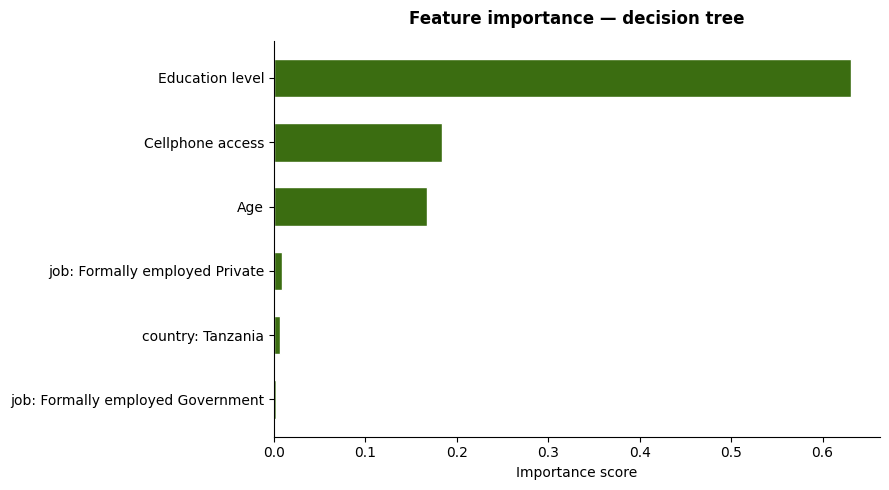

In [ ]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': tree.feature_importances_
}).sort_values('importance', ascending=True)

# Clean labels
importance_df['label'] = (importance_df['feature']
    .str.replace('ohe_job_', 'job: ', regex=False)
    .str.replace('ohe_country_', 'country: ', regex=False)
    .str.replace('bin_location_type', 'Urban location', regex=False)
    .str.replace('bin_cellphone_access', 'Cellphone access', regex=False)
    .str.replace('bin_gender', 'Gender (Male=1)', regex=False)
    .str.replace('ord_education_level', 'Education level', regex=False)
    .str.replace('age_of_respondent', 'Age', regex=False)
)

# Only show features with non-zero importance
importance_df = importance_df[importance_df['importance'] > 0]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importance_df['label'], importance_df['importance'],
               color='#3B6D11', edgecolor='white', height=0.6)
ax.set_title('Feature importance — decision tree', fontweight='bold', pad=12)
ax.set_xlabel('Importance score')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

Why feature importance looks different from logistic regression:

Logistic regression coefficients measure the direction and strength of a linear relationship between each feature and the target, holding all other features constant. Every feature gets a weight regardless of how often it's actually used.
Decision tree importance measures how much each feature reduced prediction error across all the splits that used it. A feature only gets importance if the tree actually chose to split on it. Features the tree never split on get zero.

The key reason they disagree here is cellphone access. In the logistic regression it likely has a strong positive coefficient because it has a genuine linear relationship with bank account ownership. But in the decision tree, if cellphone access tends to co-occur with formal employment or higher education, the tree might split on those instead and never get around to using cellphone access — so its importance drops to zero even though it's a genuinely useful signal.
This is called feature redundancy — when two features carry similar information, a decision tree picks one and ignores the other, while logistic regression splits the credit between both.
The practical takeaway: neither ranking is "correct". They're two different lenses on the same data. Where both models agree a feature matters, you can be confident. Where they disagree, it's worth investigating whether features are correlated with each other.

EXAMPLE:
A strong negative coefficient for Tanzania in linear regression means: on average, across the whole dataset, being in Tanzania is associated with a lower probability of having a bank account — compared to Kenya (the baseline country that was dropped). It's a single number summarising the entire relationship, in one direction.
What the decision tree is saying: The tree found Tanzania useful somewhere in its branching logic — but not necessarily as a simple negative signal. It might have learned something like: "among people in Tanzania who also have a cellphone and formal employment, the bank account rate is actually relatively high." The tree can discover these pockets of exception that the logistic regression smooths over.

---
### Step 7 — Tune max_depth

Try different tree depths and see how training vs validation AUC changes. If training AUC is much higher than validation AUC, the tree is overfitting.

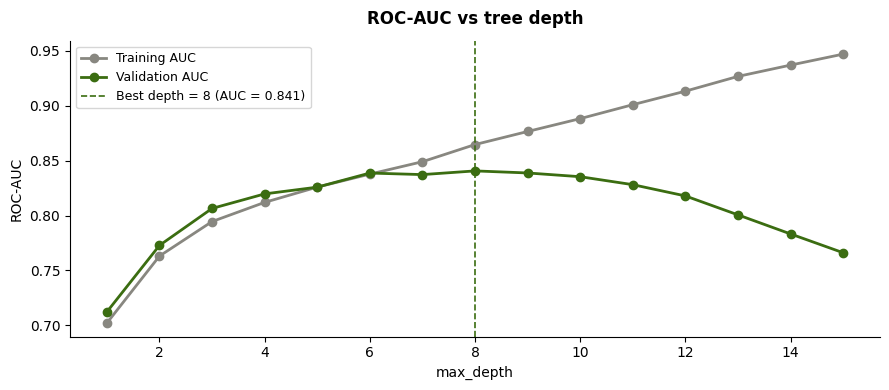

Best max_depth    : 8
Best validation AUC: 0.8407

Where training AUC >> validation AUC → overfitting (tree memorising training data)


In [ ]:
depths = range(1, 16)
train_aucs, val_aucs = [], []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    t.fit(X_train, y_train)
    train_aucs.append(roc_auc_score(y_train, t.predict_proba(X_train)[:, 1]))
    val_aucs.append(roc_auc_score(y_val,   t.predict_proba(X_val)[:, 1]))

best_depth = depths[val_aucs.index(max(val_aucs))]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depths, train_aucs, 'o-', color='#888780', lw=2, label='Training AUC')
ax.plot(depths, val_aucs,   'o-', color='#3B6D11', lw=2, label='Validation AUC')
ax.axvline(best_depth, color='#3B6D11', linestyle='--', lw=1.2,
           label=f'Best depth = {best_depth} (AUC = {max(val_aucs):.3f})')
ax.set_title('ROC-AUC vs tree depth', fontweight='bold', pad=12)
ax.set_xlabel('max_depth')
ax.set_ylabel('ROC-AUC')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Best max_depth    : {best_depth}')
print(f'Best validation AUC: {max(val_aucs):.4f}')
print(f'\nWhere training AUC >> validation AUC → overfitting (tree memorising training data)')

---
### Summary

| | Logistic Regression | Decision Tree |
|---|---|---|
| Needs feature scaling | Yes | No |
| Handles non-linearity | No | Yes |
| Interpretable | Coefficients | Visual tree |
| Main risk | Underfitting | Overfitting |
| Key parameter | — | `max_depth` |

**Next step:** Try a **Random Forest** — it combines many decision trees and typically outperforms a single tree significantly.

---
### Simplifying the Decision Tree

In [13]:
tree = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)


In [14]:
friendly_names = {
    'bin_cellphone_access': 'Has cellphone',
    'ord_education_level':  'Education level',
    'bin_location_type':    'Lives in city',
    'bin_gender':           'Gender (male)',
    'age_of_respondent':    'Age',
    'ohe_country_Rwanda':   'Country: Rwanda',
    'ohe_country_Tanzania': 'Country: Tanzania',
    'ohe_country_Uganda':   'Country: Uganda',
    'ohe_job_Formally employed Government': 'Job: Gov. employee',
    'ohe_job_Formally employed Private':    'Job: Private employee',
    'ohe_job_Farming and Fishing':          'Job: Farming/fishing',
    'ohe_job_Self employed':                'Job: Self-employed',
    'ohe_job_Informally employed':          'Job: Informal work',
    'ohe_job_No Income':                    'Job: No income',
    'ohe_job_Remittance Dependent':         'Job: Remittance',
    'ohe_job_Government Dependent':         'Job: Gov. dependent',
    'ohe_job_Other Income':                 'Job: Other income',
}

X_train_renamed = X_train.rename(columns=friendly_names)
X_val_renamed   = X_val.rename(columns=friendly_names)

tree.fit(X_train_renamed, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42)

In [16]:
ax.set_title(
    'How the model decides: follow the branches from top to bottom.\n'
    'Blue = likely has a bank account   |   Orange = likely does not',
    fontsize=11, pad=14
)

Text(0.5, 1.0, 'How the model decides: follow the branches from top to bottom.\nBlue = likely has a bank account   |   Orange = likely does not')

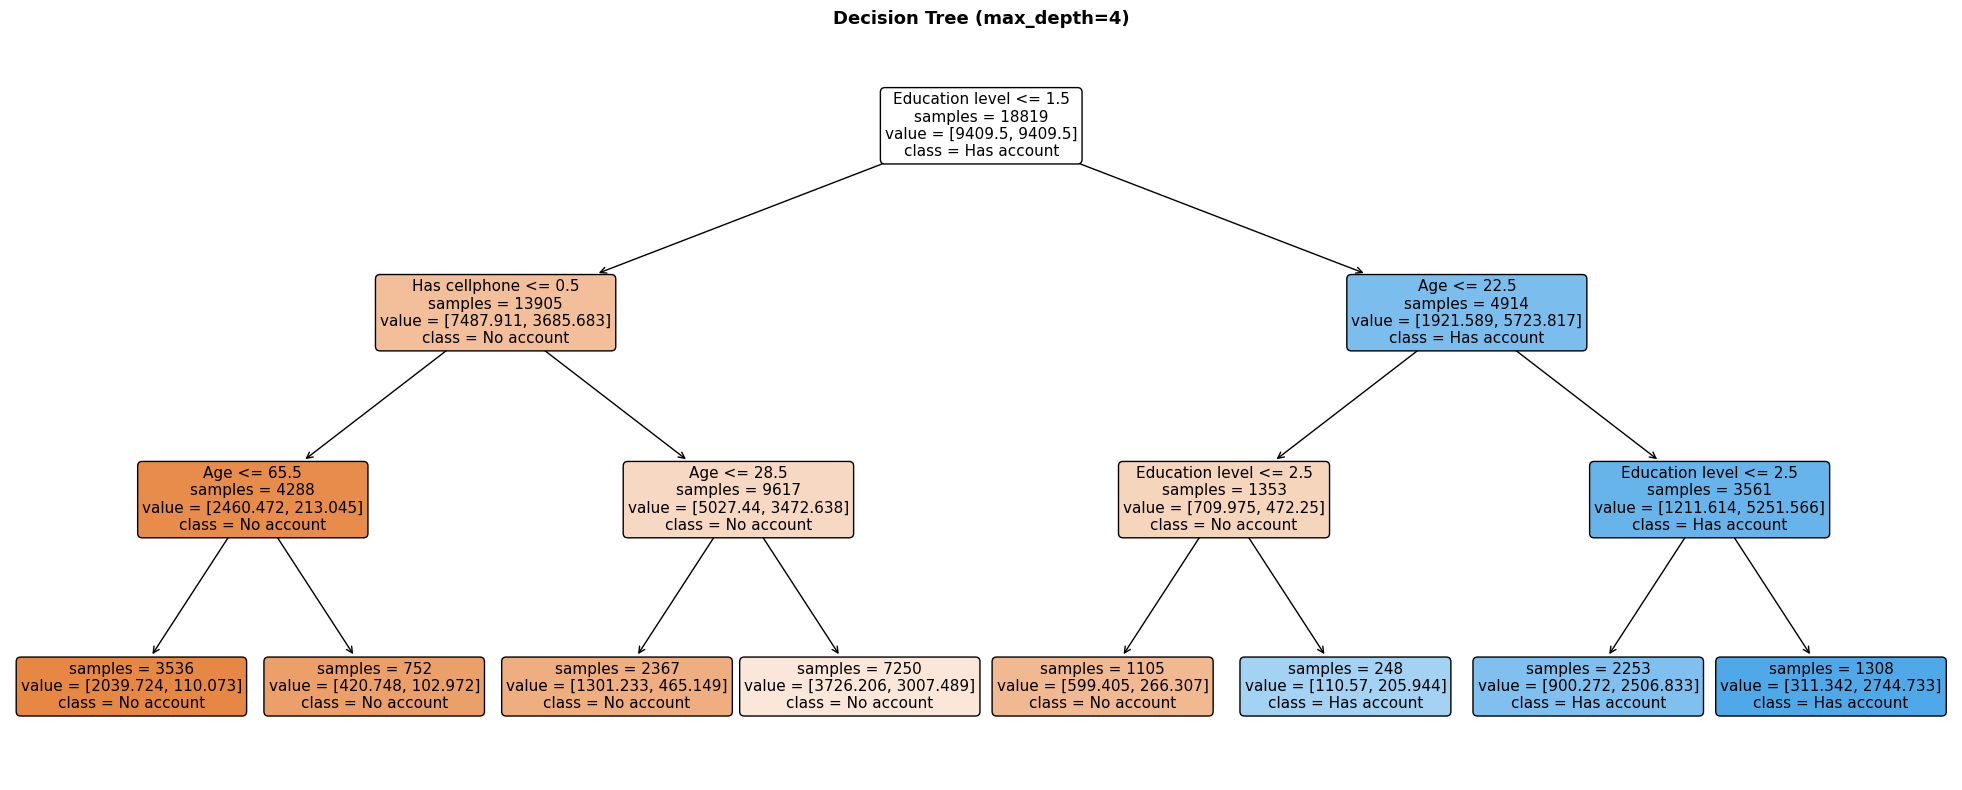

In [18]:
fig, ax = plt.subplots(figsize=(20, 8))

plot_tree(
    tree,
    feature_names=X_train_renamed.columns,
    class_names=['No account', 'Has account'],
    filled=True,
    rounded=True,
    impurity=False,   # hide Gini score
    proportion=False, # hide sample counts
    fontsize=11,
    ax=ax
)

ax.set_title('Decision Tree (max_depth=4)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()